# 02 - Garbage Classification: 2D CNN

Dataset rác là bài toán **image classification**, phù hợp trực tiếp với CNN 2D. Nguồn mô tả bên ngoài xác nhận dataset Kaggle `zlatan599/garbage-dataset-classification` là một dataset ảnh phân loại rác; số lớp/cấu trúc thư mục nên được đọc trực tiếp từ file bạn tải về để notebook không giả định sai cấu trúc. citeturn0search2


## Kiến thức CNN được áp dụng

Notebook này minh họa trực tiếp các khái niệm:

- **Tensor / Channel / Feature map**
- **Convolution**: kernel/filter quét trên vùng cục bộ
- **Local connectivity**
- **Parameter sharing**
- **ReLU**: đưa phi tuyến vào mạng
- **Pooling / Downsampling**
- **Receptive field** tăng dần qua các block
- **Hierarchical feature extraction**
- **Function composition**:

\[
F = f_{classifier}\circ f_{block3}\circ f_{block2}\circ f_{block1}
\]

Mỗi block có dạng:

\[
f_{block}=f_{pool}\circ f_{ReLU}\circ f_{Conv}
\]

- **Loss → Backpropagation → Gradient → Optimizer** để học kernel/weights.


In [1]:

# ============================================================
# CNN FROM SCRATCH IN PYTORCH - COMMON SETUP
# ============================================================
import os, random, time, json, copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# =========================
# 1. ĐƯỜNG DẪN DATASET (local)
# =========================
DATA_ROOT = Path("../data/Garbage_Dataset_Classification")
IMAGES_DIR = DATA_ROOT / "images"
METADATA_CSV = DATA_ROOT / "metadata.csv"

print("DATA_ROOT exists:", DATA_ROOT.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())
print("METADATA_CSV exists:", METADATA_CSV.exists())

df = pd.read_csv(METADATA_CSV)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

DATA_ROOT exists: True
IMAGES_DIR exists: True
METADATA_CSV exists: True
Shape: (13901, 2)
Columns: ['filename', 'label']


,filename,label
0,cardboard_02038.jpg,cardboard
1,cardboard_02320.jpg,cardboard
2,cardboard_01728.jpg,cardboard
3,cardboard_00093.jpg,cardboard
4,cardboard_00094.jpg,cardboard


In [3]:
# =========================
# 2. XÁC ĐỊNH CỘT PATH/LABEL TRONG metadata.csv
# =========================
path_col = "filename"
label_col = "label"

classes = sorted(df[label_col].unique().tolist())
print("Số lớp:", len(classes))
print("Classes:", classes)
print(df[label_col].value_counts())

Số lớp: 6
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
label
glass        2500
trash        2500
paper        2315
plastic      2288
cardboard    2214
metal        2084
Name: count, dtype: int64


In [4]:
# =========================
# 3. TRANSFORM + CUSTOM DATASET (đọc từ metadata.csv)
# =========================
from PIL import Image

IMG_SIZE = 128
BATCH_SIZE = 64

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

class GarbageCSVDataset(Dataset):
    def __init__(self, dataframe, images_dir, path_col, label_col, classes, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.path_col = path_col
        self.label_col = label_col
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        label_name = row[self.label_col]
        img_path = self.images_dir / str(label_name) / str(row[self.path_col])  # ← SỬA Ở ĐÂY
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.class_to_idx[label_name]
        return img, label

# full_dataset chỉ dùng để giữ .classes cho các cell phía sau, không train trực tiếp trên nó
full_dataset = GarbageCSVDataset(df, IMAGES_DIR, path_col, label_col, classes, transform=eval_tf)
print("Total images:", len(full_dataset))

# Chia train/val/test theo tỉ lệ 70/15/15
n = len(df)
n_train = int(0.70*n)
n_val = int(0.15*n)

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n, generator=g).tolist()
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train+n_val]
test_idx  = perm[n_train+n_val:]

train_df = df.iloc[train_idx]
val_df   = df.iloc[val_idx]
test_df  = df.iloc[test_idx]

train_ds = GarbageCSVDataset(train_df, IMAGES_DIR, path_col, label_col, classes, transform=train_tf)
val_ds   = GarbageCSVDataset(val_df,   IMAGES_DIR, path_col, label_col, classes, transform=eval_tf)
test_ds  = GarbageCSVDataset(test_df,  IMAGES_DIR, path_col, label_col, classes, transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(len(train_ds), len(val_ds), len(test_ds))

Total images: 13901
9730 2085 2086


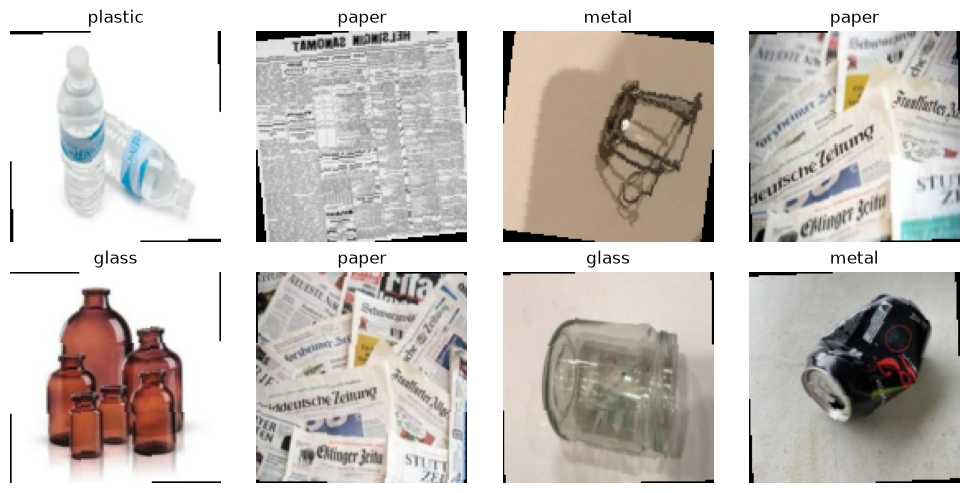

In [5]:

# =========================
# 4. VISUALIZE SAMPLE
# =========================
images, labels = next(iter(train_loader))
grid = images[:8].clone()
grid = (grid * 0.5 + 0.5).clamp(0,1)

fig, axes = plt.subplots(2,4, figsize=(10,5))
for ax, img, lab in zip(axes.ravel(), grid, labels[:8]):
    ax.imshow(img.permute(1,2,0))
    ax.set_title(full_dataset.classes[lab])
    ax.axis("off")
plt.tight_layout()
plt.show()


In [6]:

# =========================
# 5. 2D CNN
# =========================
class CNN2D_Garbage(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1,1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = CNN2D_Garbage(len(full_dataset.classes)).to(DEVICE)
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


CNN2D_Garbage(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, a

In [7]:

# =========================
# 6. TRAIN
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item()*len(yb)
            correct += (logits.argmax(1)==yb).sum().item()
            total += len(yb)
    return total_loss/total, correct/total

EPOCHS = 15
history = {"train_loss":[],"val_loss":[],"train_acc":[],"val_acc":[]}
best_state, best_val = None, float("inf")

for epoch in range(EPOCHS):
    model.train()
    running_loss, correct, total = 0,0,0

    for xb,yb in train_loader:
        xb,yb = xb.to(DEVICE),yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits,yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()*len(yb)
        correct += (logits.argmax(1)==yb).sum().item()
        total += len(yb)

    tr_loss, tr_acc = running_loss/total, correct/total
    va_loss, va_acc = evaluate(val_loader)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_loss < best_val:
        best_val = va_loss
        best_state = copy.deepcopy(model.state_dict())

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
          f"val loss={va_loss:.4f}, acc={va_acc:.4f}")

model.load_state_dict(best_state)


Epoch 01/15 | train loss=1.4644, acc=0.4358 | val loss=1.3648, acc=0.4978
Epoch 02/15 | train loss=1.3184, acc=0.5044 | val loss=1.3377, acc=0.4959
Epoch 03/15 | train loss=1.2337, acc=0.5456 | val loss=1.2705, acc=0.5185
Epoch 04/15 | train loss=1.1941, acc=0.5612 | val loss=1.1554, acc=0.5655
Epoch 05/15 | train loss=1.1341, acc=0.5846 | val loss=1.1259, acc=0.5899
Epoch 06/15 | train loss=1.0938, acc=0.6020 | val loss=1.2146, acc=0.5621
Epoch 07/15 | train loss=1.0659, acc=0.6111 | val loss=1.0404, acc=0.6192
Epoch 08/15 | train loss=1.0410, acc=0.6221 | val loss=1.1155, acc=0.6019
Epoch 09/15 | train loss=1.0003, acc=0.6401 | val loss=0.9921, acc=0.6504
Epoch 10/15 | train loss=0.9771, acc=0.6445 | val loss=0.9600, acc=0.6585
Epoch 11/15 | train loss=0.9668, acc=0.6531 | val loss=1.0001, acc=0.6293
Epoch 12/15 | train loss=0.9628, acc=0.6527 | val loss=0.9364, acc=0.6633
Epoch 13/15 | train loss=0.9118, acc=0.6736 | val loss=0.9945, acc=0.6288
Epoch 14/15 | train loss=0.9162, acc=0

<All keys matched successfully>

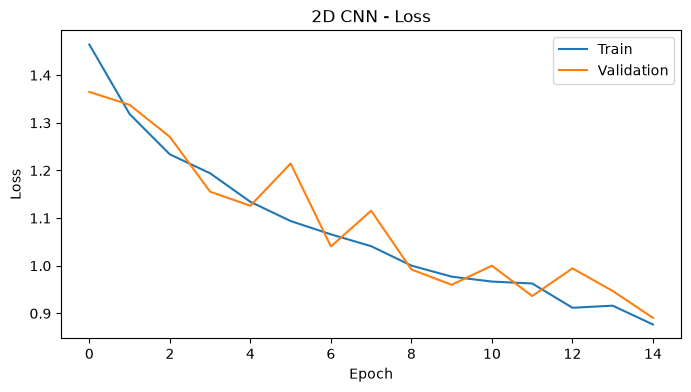

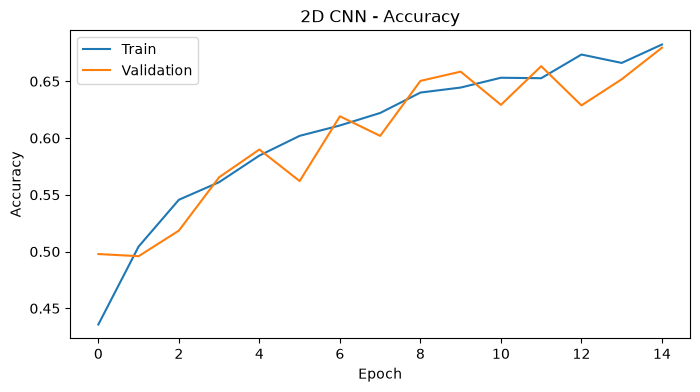

In [8]:

# =========================
# 7. CURVES
# =========================
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("2D CNN - Loss"); plt.legend(); plt.show()

plt.figure(figsize=(8,4))
plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("2D CNN - Accuracy"); plt.legend(); plt.show()


              precision    recall  f1-score   support

   cardboard     0.6972    0.7391    0.7175       299
       glass     0.6131    0.7902    0.6905       367
       metal     0.7431    0.6331    0.6837       338
       paper     0.6523    0.7179    0.6835       358
     plastic     0.5955    0.6127    0.6040       346
       trash     0.7868    0.5370    0.6384       378

    accuracy                         0.6697      2086
   macro avg     0.6813    0.6717    0.6696      2086
weighted avg     0.6815    0.6697    0.6683      2086



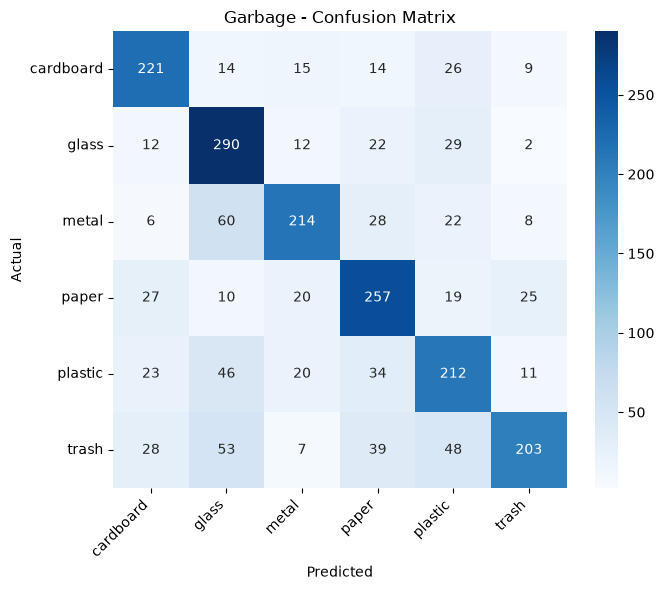

In [9]:

# =========================
# 8. TEST + CONFUSION MATRIX
# =========================
model.eval()
preds, truths = [], []
with torch.no_grad():
    for xb,yb in test_loader:
        logits = model(xb.to(DEVICE))
        preds.extend(logits.argmax(1).cpu().numpy())
        truths.extend(yb.numpy())

print(classification_report(truths, preds, target_names=full_dataset.classes, digits=4))

cm = confusion_matrix(truths, preds)
plt.figure(figsize=(max(7,len(full_dataset.classes)*0.7), max(6,len(full_dataset.classes)*0.6)))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Garbage - Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Liên hệ với lý thuyết

Đây là trường hợp CNN 2D tự nhiên nhất: kernel \(3\times3\) nhìn vùng pixel cục bộ; cùng kernel được dùng lại trên toàn ảnh (**parameter sharing**); các block liên tiếp mở rộng **receptive field** và học từ cạnh/texture đến hình dạng và đặc trưng cấp cao. `ReLU` tạo phi tuyến và `MaxPool2d` giảm kích thước không gian.